In [27]:
import pandas as pd
import numpy as np
import pyro
import torch

np.random.seed(13625442)

# 1: Load the Dataset

In [28]:
ratings_df = pd.read_csv("Dataset/jester_ratings.csv")  
jokes_df = pd.read_csv("Dataset/jester_items.csv")

print(f"Ratings: {ratings_df.shape}\nJokes: {jokes_df.shape}")
print(ratings_df.head())
print(jokes_df.head())

Ratings: (1761439, 3)
Jokes: (150, 2)
   userId  jokeId  rating
0       1       5   0.219
1       1       7  -9.281
2       1       8  -9.281
3       1      13  -6.781
4       1      15   0.875
   jokeId                                           jokeText
0       1  A man visits the doctor. The doctor says "I ha...
1       2  This couple had an excellent relationship goin...
2       3  Q. What's 200 feet long and has 4 teeth? \n\nA...
3       4  Q. What's the difference between a man and a t...
4       5  Q.\tWhat's O. J. Simpson's Internet address? \...


# 2: Filter the Dataset to be smaller 

In [29]:
JOKE_COUNT = 50
USER_COUNT = 1000

#order jokes by the jokes that are rated the most often and take the top JOKE_COUNT jokes
top_jokeIds = ratings_df['jokeId'].value_counts().head(JOKE_COUNT).index.tolist()

#copy the dataset with only the jokes from last step
filtered_df = ratings_df[ratings_df['jokeId'].isin(top_jokeIds)].copy()

#order the users by how many of the jokes they rated in our filtered_df, 
#then keep the users that rated more than 4/5ths of the jokes
user_counts = filtered_df['userId'].value_counts()
active_users = user_counts[user_counts >= (JOKE_COUNT//5)*4].index
filtered_df = filtered_df[filtered_df['userId'].isin(active_users)]

#rearrange the df such that every row is a single user and every column is a joke
pivot_df = filtered_df.pivot(index='userId', columns='jokeId', values='rating')[:USER_COUNT]

#mask out NANs 
mask_np = pivot_df.notna().astype(float).values
mask_tensor = torch.tensor(mask_np, dtype=torch.float32)

def binarize_rating(val):
    """Convert positive values to 1.0 and negative values to 0.0."""
    return 1.0 if val > 0.0 else 0.0

#create tensor for model
binary_ratings_np = pivot_df.map(binarize_rating).values
ratings_tensor = torch.tensor(binary_ratings_np, dtype=torch.float32)

#reconstruct jokeText for pretty printing later
ordered_jokeIds = pivot_df.columns.tolist()
top_jokes_text = [
    jokes_df[jokes_df['jokeId'] == j_id]['jokeText'].values[0] 
    for j_id in ordered_jokeIds
]

print(f"Data ready! Matrix shape: {ratings_tensor.shape} (Users x Jokes)")

Data ready! Matrix shape: torch.Size([1000, 50]) (Users x Jokes)


# 2.5 Print the Funniest Joke (for fun)

In [30]:

joke_scores = binary_ratings_np.sum(axis=0)
sorted_joke_indices = np.argsort(joke_scores)

funniest_joke_idx = sorted_joke_indices[-1]
highest_score = joke_scores[funniest_joke_idx]

print(f"Funniest Joke:\n{top_jokes_text[funniest_joke_idx]}")

Funniest Joke:
A radio conversation of a US naval 
ship with Canadian authorities ... 

Americans: Please divert your course 15 degrees to the North to avoid a
collision.

Canadians: Recommend you divert YOUR course 15 degrees to the South to 
avoid a collision.

Americans: This is the Captain of a US Navy ship.  I say again, divert 
YOUR course.

Canadians: No.  I say again, you divert YOUR course.

Americans: This is the aircraft carrier USS LINCOLN, the second largest ship in the United States' Atlantic Fleet. We are accompanied by three destroyers, three cruisers and numerous support vessels. I demand that you change your course 15 degrees north, that's ONE FIVE DEGREES NORTH, or counter-measures will be undertaken to ensure the safety of this ship.

Canadians: This is a lighthouse.  Your call.



# 3: Define the model

In [31]:
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoNormal
from pyro.optim import Adam
import torch

def ising_jester_model(user_ratings, mask):
    n_users, n_jokes = user_ratings.shape
    
    #instantiate model parameters
    h_prior = dist.Normal(torch.zeros(n_jokes), torch.ones(n_jokes))
    J_prior = dist.Normal(torch.zeros(n_jokes, n_jokes), torch.ones(n_jokes, n_jokes) * 0.1)
    
    h = pyro.sample("h", h_prior.to_event(1))
    J_raw = pyro.sample("J_raw", J_prior.to_event(2))
    
    #create symmetrical matrix and eliminate diagonal entries
    J_sym = (J_raw + J_raw.T) / 2.0
    J = J_sym - torch.diag(torch.diag(J_sym)) 
    
    with pyro.plate("users", n_users):
        observed_states = user_ratings * mask
        
        #convert {0,1} -> {-1,1}
        spins = (2.0 * observed_states - 1.0) * mask
        
        #effective field for ising learning
        effective_field = 2.0 * h + 2.0 * torch.matmul(spins, J)
        prob_funny = torch.special.expit(effective_field)

        masked_dist = dist.Bernoulli(probs=prob_funny).mask(mask.bool()).to_event(1)
        pyro.sample("obs_ratings", masked_dist, obs=user_ratings)



In [32]:
total_users, total_jokes = ratings_tensor.shape
base_train_mask = mask_tensor.clone()
test_targets = []
STEPS = 1000

#create a test set of 1 joke per user
for u in range(total_users):
    rated_indices = torch.where(mask_tensor[u] == 1.0)[0]
    target_joke = rated_indices[np.random.randint(0, len(rated_indices))].item()
    base_train_mask[u, target_joke] = 0.0
    test_targets.append((u, target_joke, ratings_tensor[u, target_joke].item()))

keep_rates = [0.10, 0.25, 0.5, 0.75, 1.0]
results_log = []


for keep_rate in keep_rates:
    #generate a mask, keeping only keep_rate% of entries
    random_dropout = (torch.rand(total_users, total_jokes) < keep_rate).float()
    sparse_train_mask = base_train_mask * random_dropout
    
    #get a count of the ratings
    ratings_count = int(sparse_train_mask.sum().item())
    
    #reset the model
    pyro.clear_param_store()
    guide = AutoNormal(ising_jester_model)
    optimizer = Adam({"lr": 0.01})
    svi = SVI(ising_jester_model, guide, optimizer, loss=Trace_ELBO())
    
    #train
    for step in range(STEPS):  
        loss = svi.step(ratings_tensor, sparse_train_mask)
        
    #extract the parameters
    post_means = guide.median()
    learned_h = post_means["h"]
    learned_J_raw = post_means["J_raw"]
    learned_J = (learned_J_raw + learned_J_raw.T) / 2.0 - torch.diag(torch.diag((learned_J_raw + learned_J_raw.T) / 2.0))
    
    #evaluate
    obs_states = ratings_tensor * sparse_train_mask
    spins = (2.0 * obs_states - 1.0) * sparse_train_mask
    eff_field = 2.0 * learned_h + 2.0 * torch.matmul(spins, learned_J)
    probs = torch.special.expit(eff_field)
    
    #accuracy
    correct, total = 0, 0
    for u, j, actual in test_targets:
        pred = 1.0 if probs[u, j].item() >= 0.5 else 0.0
        if pred == actual:
            correct += 1
        total += 1
            
    accuracy = (correct / total * 100) if total > 0 else 0
    results_log.append({"Keep Rate": keep_rate, "Active Ratings": ratings_count, "Accuracy": accuracy})
    
    print(f"Kept {keep_rate*100}% Data | Ratings Used: {ratings_count:>5} | Test Accuracy: {accuracy:.2f}%")


Kept 10.0% Data | Ratings Used:  4563 | Test Accuracy: 76.40%
Kept 25.0% Data | Ratings Used: 11720 | Test Accuracy: 77.90%
Kept 50.0% Data | Ratings Used: 23110 | Test Accuracy: 80.10%
Kept 75.0% Data | Ratings Used: 34519 | Test Accuracy: 81.00%
Kept 100.0% Data | Ratings Used: 46185 | Test Accuracy: 81.10%


In [33]:
funniest_joke_idx = torch.argmax(learned_h).item()
funniest_joke_bias = learned_h[funniest_joke_idx].item()

print(f"Funniest Joke(model edition)\n{top_jokes_text[funniest_joke_idx]}")
print(f"Intrinsic Bias (h): {funniest_joke_bias:.4f}")



Funniest Joke(model edition)
A couple of hunters are out in the woods in the deep south when one of them falls to the ground. He doesn't seem to be breathing, and his eyes are rolled back in his head. The other guy whips out his cell phone and calls 911. He gasps to the operator, "My friend is dead! What can I do?" The operator, in a calm and soothing voice, says, "Alright, take it easy. I can help. First, let's make sure he's dead." There is silence, and then a gun shot is heard. The hunter comes back on the line. "Okay. Now what??"
Intrinsic Bias (h): 0.3958


# 4: Calibration Curve

A calibration curve checks whether the model's predicted probabilities are trustworthy.
We bin all test predictions by their confidence (e.g. 0-10%, 10-20%, ...) and plot
predicted probability vs. actual fraction correct in that bin.
A perfectly calibrated model falls on the diagonal.

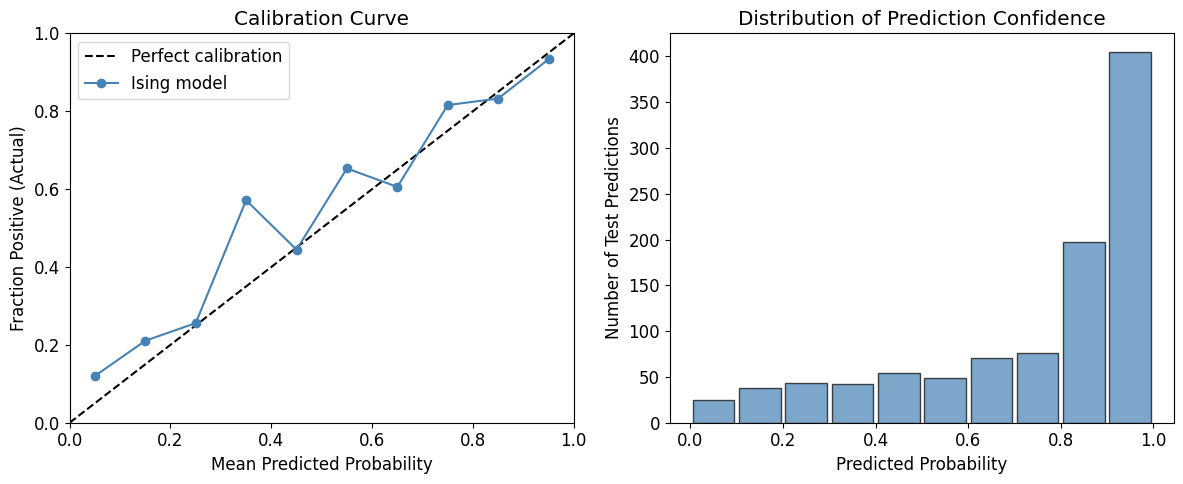

Calibration curve saved to calibration_curve.png


In [34]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 12})

# Use the fully-trained model (keep_rate=1.0, last iteration of the loop above)
# Re-compute predicted probabilities on the test set using full training mask (no extra dropout)
obs_states_full = ratings_tensor * base_train_mask
spins_full = (2.0 * obs_states_full - 1.0) * base_train_mask
eff_field_full = 2.0 * learned_h + 2.0 * torch.matmul(spins_full, learned_J)
probs_full = torch.special.expit(eff_field_full)

# Gather predicted probability and ground truth for each test target
pred_probs = np.array([probs_full[u, j].item() for u, j, _ in test_targets])
actuals    = np.array([actual              for _, _, actual in test_targets])

# Bin predictions into 10 equal-width buckets
N_BINS = 10
bins = np.linspace(0, 1, N_BINS + 1)
bin_centers, bin_acc, bin_counts = [], [], []

for i in range(N_BINS):
    lo, hi = bins[i], bins[i + 1]
    mask_bin = (pred_probs >= lo) & (pred_probs < hi)
    if mask_bin.sum() == 0:
        continue
    bin_centers.append((lo + hi) / 2)
    bin_acc.append(actuals[mask_bin].mean())
    bin_counts.append(mask_bin.sum())

bin_centers = np.array(bin_centers)
bin_acc     = np.array(bin_acc)
bin_counts  = np.array(bin_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: calibration curve
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(bin_centers, bin_acc, 'o-', color='steelblue', label='Ising model')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction Positive (Actual)')
ax.set_title('Calibration Curve')
ax.legend()
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# Right: histogram of prediction confidence
ax2 = axes[1]
ax2.bar(bin_centers, bin_counts, width=0.09, color='steelblue', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Number of Test Predictions')
ax2.set_title('Distribution of Prediction Confidence')

plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Calibration curve saved to calibration_curve.png')

# 5: Joke Clustering via Learned J Matrix

The coupling matrix J encodes how jokes relate to each other. Positive J[i,j] means
users tend to rate jokes i and j similarly and negative means they tend to disagree.
We use hierarchical clustering on J to find groups of jokes with similar taste profiles,
and plot a heatmap so the structure is visually clear.

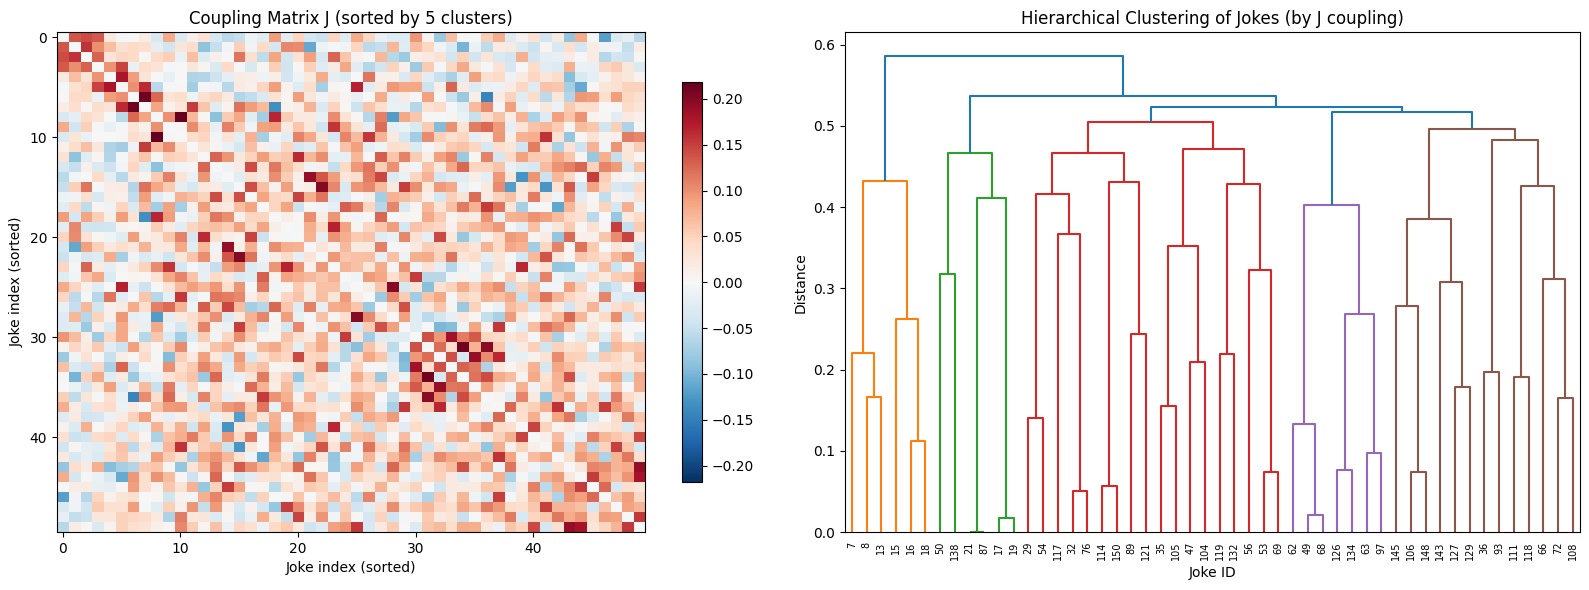

Cluster assignments (N=5):

  Cluster 1 (6 jokes, mean bias h=-0.265): joke IDs [7, 8, 13, 15, 16, 18]
  Cluster 2 (6 jokes, mean bias h=0.025): joke IDs [17, 19, 21, 50, 87, 138]
  Cluster 3 (18 jokes, mean bias h=0.084): joke IDs [29, 32, 35, 47, 53, 54, 56, 69, 76, 89, 104, 105, 114, 117, 119, 121, 132, 150]
  Cluster 4 (7 jokes, mean bias h=0.010): joke IDs [49, 62, 63, 68, 97, 126, 134]
  Cluster 5 (13 jokes, mean bias h=0.038): joke IDs [36, 66, 72, 93, 106, 108, 111, 118, 127, 129, 143, 145, 148]


In [35]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 10})

J_np = learned_J.detach().numpy()
h_np = learned_h.detach().numpy()

# Convert J into a distance matrix: high positive coupling -> similar -> small distance
J_sim = (J_np - J_np.min()) / (J_np.max() - J_np.min())  # scale to [0,1]
dist_matrix = 1.0 - J_sim
np.fill_diagonal(dist_matrix, 0.0)
dist_matrix = (dist_matrix + dist_matrix.T) / 2.0  # ensure symmetry

# Hierarchical clustering
condensed = squareform(dist_matrix)
Z = linkage(condensed, method='average')

N_CLUSTERS = 5
cluster_labels = fcluster(Z, N_CLUSTERS, criterion='maxclust')

# Sort jokes by cluster for a clean heatmap
sort_order = np.argsort(cluster_labels)
J_sorted = J_np[np.ix_(sort_order, sort_order)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: heatmap of sorted J
ax = axes[0]
vmax = np.abs(J_np).max()
im = ax.imshow(J_sorted, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title(f'Coupling Matrix J (sorted by {N_CLUSTERS} clusters)')
ax.set_xlabel('Joke index (sorted)'); ax.set_ylabel('Joke index (sorted)')

# Right: dendrogram
ax2 = axes[1]
dendrogram(Z, ax=ax2, color_threshold=Z[-(N_CLUSTERS-1), 2],
           labels=[str(jid) for jid in ordered_jokeIds],
           leaf_rotation=90, leaf_font_size=7)
ax2.set_title('Hierarchical Clustering of Jokes (by J coupling)')
ax2.set_xlabel('Joke ID'); ax2.set_ylabel('Distance')

plt.tight_layout()
plt.savefig('joke_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

# Print cluster summary
print(f'Cluster assignments (N={N_CLUSTERS}):\n')
for c in range(1, N_CLUSTERS + 1):
    idxs = np.where(cluster_labels == c)[0]
    joke_ids_in_cluster = [ordered_jokeIds[i] for i in idxs]
    mean_h = h_np[idxs].mean()
    print(f'  Cluster {c} ({len(idxs)} jokes, mean bias h={mean_h:.3f}): joke IDs {joke_ids_in_cluster}')

# 6: Reusable Training and Metrics Helpers

To compare the Ising model fairly against baselines and across different settings,
we wrap training and evaluation into helper functions. We also add several metrics
beyond plain accuracy, since accuracy alone can be misleading when one class is more
common than the other. The metrics we track are:

- Accuracy: fraction of held-out ratings predicted correctly.
- AUC: ranking quality, robust to class imbalance.
- Log loss: penalizes confident wrong answers, rewards good probabilities.
- Brier score: mean squared error between predicted probability and truth.
- ECE (Expected Calibration Error): how far predicted confidence drifts from reality.

Note: we hold out one rating per user, the same split used
everywhere below, so every model and baseline is scored on exactly the same targets.

In [36]:
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss

def expected_calibration_error(probs_arr, labels_arr, n_bins=10):
    """Average gap between confidence and accuracy across probability bins."""
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    N = len(probs_arr)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        sel = (probs_arr >= lo) & (probs_arr < hi)
        if sel.sum() == 0:
            continue
        conf = probs_arr[sel].mean()
        acc = labels_arr[sel].mean()
        ece += (sel.sum() / N) * abs(conf - acc)
    return ece

def all_metrics(probs_arr, labels_arr):
    """Compute the full metric suite from predicted probabilities and labels."""
    preds = (probs_arr >= 0.5).astype(float)
    acc = (preds == labels_arr).mean()
    # AUC and log loss need both classes present and probs strictly inside (0,1)
    eps = 1e-7
    clipped = np.clip(probs_arr, eps, 1 - eps)
    try:
        auc = roc_auc_score(labels_arr, probs_arr)
    except ValueError:
        auc = float('nan')
    ll = log_loss(labels_arr, clipped, labels=[0, 1])
    brier = brier_score_loss(labels_arr, probs_arr)
    ece = expected_calibration_error(probs_arr, labels_arr)
    return {"accuracy": acc, "auc": auc, "log_loss": ll, "brier": brier, "ece": ece}


def train_ising(train_mask, steps=1000, lr=0.01, j_prior_scale=0.1, seed=None):
    """Train the Ising model on a given training mask and return learned params.

    j_prior_scale controls how strongly coupled the jokes are allowed to be a priori.
    Smaller values pull J toward zero (jokes treated as more independent); larger
    values allow stronger pairwise interactions. This is the model knob we sweep later.
    """
    if seed is not None:
        pyro.set_rng_seed(seed)

    # Model with a configurable J prior scale (mirrors ising_jester_model otherwise)
    def model(user_ratings, mask):
        n_users, n_jokes = user_ratings.shape
        h_prior = dist.Normal(torch.zeros(n_jokes), torch.ones(n_jokes))
        J_prior = dist.Normal(torch.zeros(n_jokes, n_jokes),
                              torch.ones(n_jokes, n_jokes) * j_prior_scale)
        h = pyro.sample("h", h_prior.to_event(1))
        J_raw = pyro.sample("J_raw", J_prior.to_event(2))
        J_sym = (J_raw + J_raw.T) / 2.0
        J = J_sym - torch.diag(torch.diag(J_sym))
        with pyro.plate("users", n_users):
            observed_states = user_ratings * mask
            spins = (2.0 * observed_states - 1.0) * mask
            effective_field = 2.0 * h + 2.0 * torch.matmul(spins, J)
            prob_funny = torch.special.expit(effective_field)
            masked_dist = dist.Bernoulli(probs=prob_funny).mask(mask.bool()).to_event(1)
            pyro.sample("obs_ratings", masked_dist, obs=user_ratings)

    pyro.clear_param_store()
    guide = AutoNormal(model)
    optimizer = Adam({"lr": lr})
    svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
    for _ in range(steps):
        svi.step(ratings_tensor, train_mask)

    post = guide.median()
    h_learned = post["h"]
    Jr = post["J_raw"]
    J_learned = (Jr + Jr.T) / 2.0 - torch.diag(torch.diag((Jr + Jr.T) / 2.0))
    return h_learned, J_learned


def ising_test_probs(h_learned, J_learned, train_mask):
    """Predicted probabilities for every (user, joke) given learned params."""
    obs = ratings_tensor * train_mask
    spins = (2.0 * obs - 1.0) * train_mask
    field = 2.0 * h_learned + 2.0 * torch.matmul(spins, J_learned)
    return torch.special.expit(field)


# Pull predicted prob + true label for the held-out targets into flat arrays
def gather_targets(prob_matrix):
    p = np.array([prob_matrix[u, j].item() for u, j, _ in test_targets])
    y = np.array([actual for _, _, actual in test_targets])
    return p, y

print("Helpers defined.")

Helpers defined.


# 7: Baseline Comparisons

An accuracy number only means something next to a baseline. If most ratings are positive,
a model that blindly guesses "funny" every time will already look decent, so we need to
know what the trivial strategies score before crediting the Ising model with anything.

We compare against three baselines, all evaluated on the same held-out rating per user:

1. Global majority: always predict the single most common label in the training data.
2. Per-joke majority: predict each joke's own majority label (some jokes are just more
   widely liked than others, and this captures that without any interaction modeling).
3. User mean: predict based on whether a user tends to rate things positively overall.

The per-joke and user-mean baselines are the honest bar to beat, because they already
capture the easy signal. The Ising model has to earn its keep by modeling the pairwise
structure those baselines ignore.

In [37]:
# Build the full-data training mask (everything except the held-out targets)
full_train_mask = base_train_mask.clone()

train_obs = ratings_tensor * full_train_mask  # observed labels (0/1), unobserved = 0
train_mask_bool = full_train_mask.bool()

# --- Baseline 1: global majority ---
observed_vals = ratings_tensor[train_mask_bool]
global_rate = observed_vals.mean().item()  # fraction of 1s among observed
global_pred_label = 1.0 if global_rate >= 0.5 else 0.0

# --- Baseline 2: per-joke majority (probability = fraction funny for that joke) ---
joke_pos = (ratings_tensor * full_train_mask).sum(dim=0)
joke_cnt = full_train_mask.sum(dim=0).clamp(min=1)
joke_rate = (joke_pos / joke_cnt)  # per joke P(funny)

# --- Baseline 3: user mean (probability = that user's own positive rate) ---
user_pos = (ratings_tensor * full_train_mask).sum(dim=1)
user_cnt = full_train_mask.sum(dim=1).clamp(min=1)
user_rate = (user_pos / user_cnt)

# Evaluate each baseline on the held-out targets
y_true = np.array([actual for _, _, actual in test_targets])

global_probs = np.full(len(test_targets), global_rate)
jokemaj_probs = np.array([joke_rate[j].item() for _, j, _ in test_targets])
usermean_probs = np.array([user_rate[u].item() for u, _, _ in test_targets])

baseline_results = {
    "Global majority": all_metrics(global_probs, y_true),
    "Per-joke majority": all_metrics(jokemaj_probs, y_true),
    "User mean": all_metrics(usermean_probs, y_true),
}

print(f"Class balance in training data: {global_rate*100:.1f}% positive")
print(f"(So 'always predict funny' is the bar to clear: {max(global_rate, 1-global_rate)*100:.1f}% accuracy)\n")

print(f"{'Baseline':<20} {'Acc':>7} {'AUC':>7} {'LogLoss':>9} {'Brier':>7} {'ECE':>7}")
print("-" * 60)
for name, m in baseline_results.items():
    print(f"{name:<20} {m['accuracy']*100:>6.1f}% {m['auc']:>7.3f} {m['log_loss']:>9.3f} {m['brier']:>7.3f} {m['ece']:>7.3f}")

Class balance in training data: 73.4% positive
(So 'always predict funny' is the bar to clear: 73.4% accuracy)

Baseline                 Acc     AUC   LogLoss   Brier     ECE
------------------------------------------------------------
Global majority        74.9%   0.500     0.564   0.188   0.015
Per-joke majority      76.8%   0.666     0.525   0.172   0.024
User mean              79.8%   0.766     0.468   0.149   0.032


# 8: Ising Model on the Full Metric Suite

Now we score the trained Ising model with the same metrics and drop it into the table
next to the baselines. This is the head-to-head comparison: if the Ising model is doing
real work, it should beat the per-joke baseline on the ranking and probability metrics
(AUC, log loss, Brier), not just on raw accuracy where the gap is often small.

Model                    Acc     AUC   LogLoss   Brier     ECE
------------------------------------------------------------
Global majority        74.9%   0.500     0.564   0.188   0.015
Per-joke majority      76.8%   0.666     0.525   0.172   0.024
User mean              79.8%   0.766     0.468   0.149   0.032
Ising model            80.9%   0.830     0.422   0.133   0.024  <-- our model


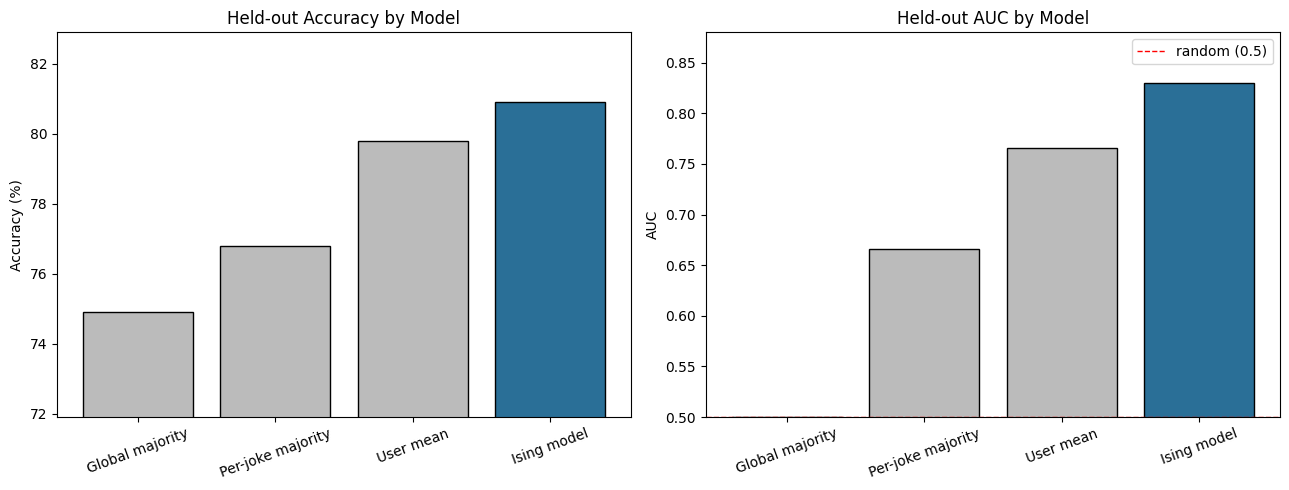


Saved model_comparison.png


In [38]:
# Train one clean Ising model on the full training data
h_full, J_full = train_ising(full_train_mask, steps=1000, lr=0.01, j_prior_scale=0.1, seed=0)
ising_prob_matrix = ising_test_probs(h_full, J_full, full_train_mask)
ising_probs, _ = gather_targets(ising_prob_matrix)

ising_metrics = all_metrics(ising_probs, y_true)

# Combined table
all_results = dict(baseline_results)
all_results["Ising model"] = ising_metrics

print(f"{'Model':<20} {'Acc':>7} {'AUC':>7} {'LogLoss':>9} {'Brier':>7} {'ECE':>7}")
print("-" * 60)
for name, m in all_results.items():
    star = "  <-- our model" if name == "Ising model" else ""
    print(f"{name:<20} {m['accuracy']*100:>6.1f}% {m['auc']:>7.3f} {m['log_loss']:>9.3f} {m['brier']:>7.3f} {m['ece']:>7.3f}{star}")

# Bar chart comparing accuracy and AUC across models
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
names = list(all_results.keys())
colors = ['#bbbbbb', '#bbbbbb', '#bbbbbb', '#2a6f97']

accs = [all_results[n]['accuracy'] * 100 for n in names]
axes[0].bar(names, accs, color=colors, edgecolor='black')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Held-out Accuracy by Model')
axes[0].set_ylim(min(accs) - 3, max(accs) + 2)
axes[0].tick_params(axis='x', rotation=20)

aucs = [all_results[n]['auc'] for n in names]
axes[1].bar(names, aucs, color=colors, edgecolor='black')
axes[1].set_ylabel('AUC')
axes[1].set_title('Held-out AUC by Model')
axes[1].set_ylim(0.5, max(aucs) + 0.05)
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1, label='random (0.5)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved model_comparison.png')

# 9: Data-Fraction Sweep, Averaged Over Seeds

The original experiment varied how much training data the model sees and showed accuracy
climbing as data grows. The weakness was that each point came from a single random run, so
some of the wiggle could be luck rather than signal. Here we repeat each data fraction over
several random seeds and plot the mean with error bars, alongside the per joke baseline so
the gain from more data is easy to read against a fixed reference.

This directly addresses the rubric's ask to measure how performance improves with more
training data, now with the noise averaged out.

Keep  10.0% | Acc 76.37% +/- 0.19 | AUC 0.677 +/- 0.005
Keep  25.0% | Acc 77.63% +/- 0.62 | AUC 0.783 +/- 0.004
Keep  50.0% | Acc 79.90% +/- 0.73 | AUC 0.819 +/- 0.007
Keep  75.0% | Acc 80.73% +/- 0.68 | AUC 0.831 +/- 0.006
Keep 100.0% | Acc 80.93% +/- 0.21 | AUC 0.833 +/- 0.003


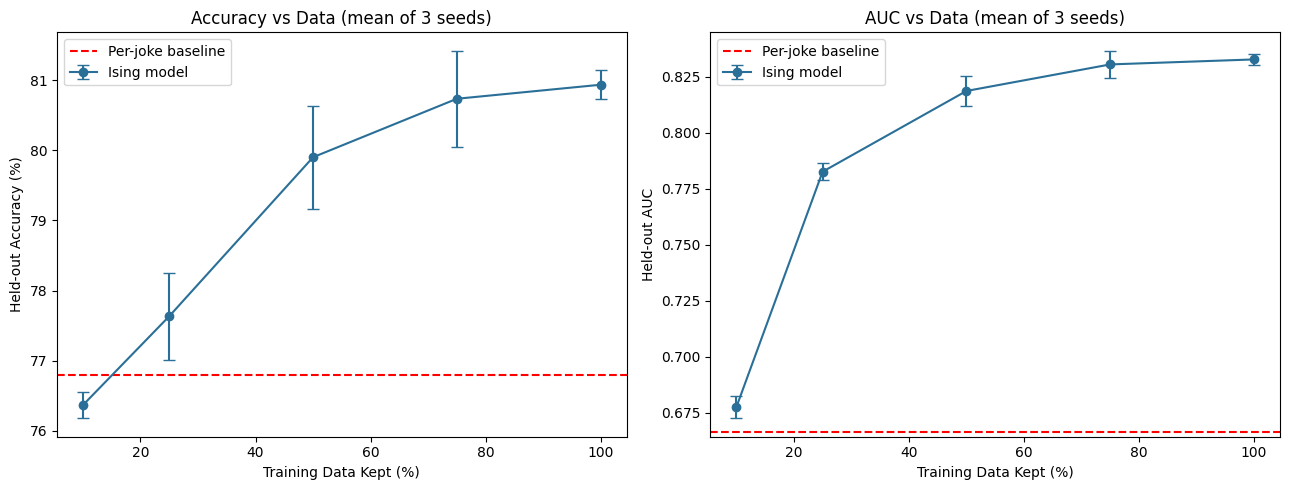


Saved data_sweep.png


In [39]:
keep_rates_sweep = [0.10, 0.25, 0.5, 0.75, 1.0]
N_SEEDS = 3

sweep_acc_mean, sweep_acc_std = [], []
sweep_auc_mean, sweep_auc_std = [], []

for kr in keep_rates_sweep:
    accs_here, aucs_here = [], []
    for s in range(N_SEEDS):
        torch.manual_seed(100 + s)
        dropout = (torch.rand(total_users, total_jokes) < kr).float()
        train_mask_kr = full_train_mask * dropout
        h_kr, J_kr = train_ising(train_mask_kr, steps=1000, lr=0.01, j_prior_scale=0.1, seed=100 + s)
        pm = ising_test_probs(h_kr, J_kr, train_mask_kr)
        p, y = gather_targets(pm)
        m = all_metrics(p, y)
        accs_here.append(m['accuracy'] * 100)
        aucs_here.append(m['auc'])
    sweep_acc_mean.append(np.mean(accs_here)); sweep_acc_std.append(np.std(accs_here))
    sweep_auc_mean.append(np.mean(aucs_here)); sweep_auc_std.append(np.std(aucs_here))
    print(f"Keep {kr*100:>5.1f}% | Acc {np.mean(accs_here):.2f}% +/- {np.std(accs_here):.2f} | AUC {np.mean(aucs_here):.3f} +/- {np.std(aucs_here):.3f}")

# Plot accuracy and AUC vs data fraction with error bars
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = [k * 100 for k in keep_rates_sweep]

baseline_acc = baseline_results["Per-joke majority"]["accuracy"] * 100
baseline_auc = baseline_results["Per-joke majority"]["auc"]

axes[0].errorbar(x, sweep_acc_mean, yerr=sweep_acc_std, fmt='o-', color='#2a6f97',
                 capsize=4, label='Ising model')
axes[0].axhline(baseline_acc, color='red', linestyle='--', label='Per-joke baseline')
axes[0].set_xlabel('Training Data Kept (%)')
axes[0].set_ylabel('Held-out Accuracy (%)')
axes[0].set_title(f'Accuracy vs Data (mean of {N_SEEDS} seeds)')
axes[0].legend()

axes[1].errorbar(x, sweep_auc_mean, yerr=sweep_auc_std, fmt='o-', color='#2a6f97',
                 capsize=4, label='Ising model')
axes[1].axhline(baseline_auc, color='red', linestyle='--', label='Per-joke baseline')
axes[1].set_xlabel('Training Data Kept (%)')
axes[1].set_ylabel('Held-out AUC')
axes[1].set_title(f'AUC vs Data (mean of {N_SEEDS} seeds)')
axes[1].legend()

plt.tight_layout()
plt.savefig('data_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved data_sweep.png')

# 10: Varying the Model Itself (Coupling Strength)

The rubric asks us to measure how a change to the model, not just the data, affects
performance. The natural knob in an Ising model is the coupling matrix J, which controls
how strongly jokes influence each other. We sweep the prior scale on J from very small
(jokes treated as almost independent, close to the per-joke baseline) up to large
(strong pairwise interactions allowed).

If the pairwise structure matters, we expect a good balance, too small and the model cannot
use joke-to-joke correlations, too large and it overfits noisy couplings. This experiment
shows whether the interaction terms, which are the whole reason to use a graphical model
here instead of independent per-joke estimates, actually help.

J prior scale  0.01 | Acc 77.30% | AUC 0.820 | LogLoss 0.465 | mean|J| 0.0092
J prior scale  0.05 | Acc 80.90% | AUC 0.838 | LogLoss 0.412 | mean|J| 0.0343
J prior scale  0.10 | Acc 80.90% | AUC 0.830 | LogLoss 0.422 | mean|J| 0.0518
J prior scale  0.25 | Acc 80.80% | AUC 0.820 | LogLoss 0.439 | mean|J| 0.0690
J prior scale  0.50 | Acc 80.90% | AUC 0.818 | LogLoss 0.445 | mean|J| 0.0736
J prior scale  1.00 | Acc 81.00% | AUC 0.818 | LogLoss 0.446 | mean|J| 0.0749


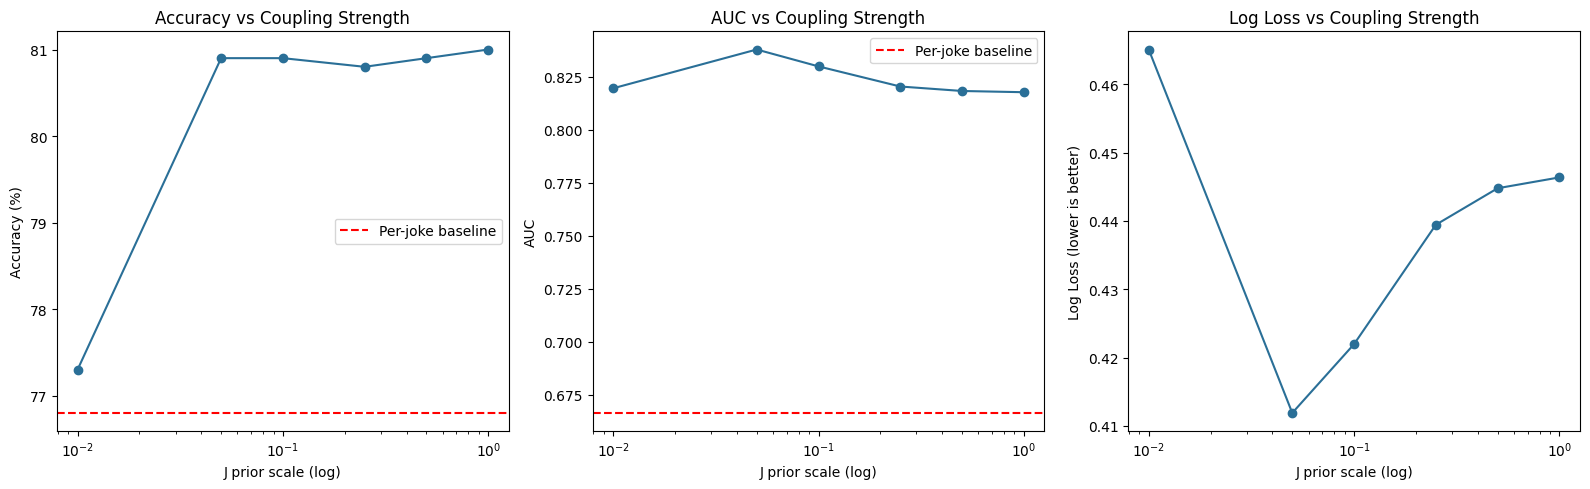


Saved coupling_sweep.png

Best J prior scale by AUC: 0.05 (AUC 0.838, Acc 80.90%)


In [40]:
j_scales = [0.01, 0.05, 0.1, 0.25, 0.5, 1.0]
js_acc, js_auc, js_ll = [], [], []

for js in j_scales:
    h_js, J_js = train_ising(full_train_mask, steps=1000, lr=0.01, j_prior_scale=js, seed=0)
    pm = ising_test_probs(h_js, J_js, full_train_mask)
    p, y = gather_targets(pm)
    m = all_metrics(p, y)
    js_acc.append(m['accuracy'] * 100)
    js_auc.append(m['auc'])
    js_ll.append(m['log_loss'])
    # also track average absolute coupling, to show the prior is doing something
    avg_abs_J = J_js.abs().sum().item() / (J_js.shape[0] * (J_js.shape[0] - 1))
    print(f"J prior scale {js:>5.2f} | Acc {m['accuracy']*100:>5.2f}% | AUC {m['auc']:.3f} | LogLoss {m['log_loss']:.3f} | mean|J| {avg_abs_J:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(j_scales, js_acc, 'o-', color='#2a6f97')
axes[0].axhline(baseline_acc, color='red', linestyle='--', label='Per-joke baseline')
axes[0].set_xscale('log'); axes[0].set_xlabel('J prior scale (log)')
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_title('Accuracy vs Coupling Strength')
axes[0].legend()

axes[1].plot(j_scales, js_auc, 'o-', color='#2a6f97')
axes[1].axhline(baseline_auc, color='red', linestyle='--', label='Per-joke baseline')
axes[1].set_xscale('log'); axes[1].set_xlabel('J prior scale (log)')
axes[1].set_ylabel('AUC'); axes[1].set_title('AUC vs Coupling Strength')
axes[1].legend()

axes[2].plot(j_scales, js_ll, 'o-', color='#2a6f97')
axes[2].set_xscale('log'); axes[2].set_xlabel('J prior scale (log)')
axes[2].set_ylabel('Log Loss (lower is better)'); axes[2].set_title('Log Loss vs Coupling Strength')

plt.tight_layout()
plt.savefig('coupling_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved coupling_sweep.png')

best_idx = int(np.argmax(js_auc))
print(f"\nBest J prior scale by AUC: {j_scales[best_idx]} (AUC {js_auc[best_idx]:.3f}, Acc {js_acc[best_idx]:.2f}%)")